In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Ecommerce Customers.csv")
df.sample(10)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
141,solischristina@gmail.com,"43102 Russo View Suite 717\nHollyport, SC 15344",SlateBlue,31.851253,12.418962,35.977652,3.251742,472.992247
324,laurajimenez@gmail.com,"06103 Erik Fields Suite 781\nJonesmouth, GA 49...",SlateBlue,33.479472,12.608889,37.229395,4.205904,559.199048
332,davisbriana@gmail.com,15298 Erickson Shore Apt. 056\nSouth Patrickfo...,MediumVioletRed,33.144234,11.737041,37.935189,2.190132,424.202827
272,jennifer24@hotmail.com,"46954 Melissa Corner\nNorth Amanda, LA 34844",SteelBlue,34.436426,13.325469,36.768603,3.371258,582.491924
20,megan33@gmail.com,"84426 Julia Vista\nNorth Teresa, KY 50756",PeachPuff,32.912785,11.365492,37.607793,4.599937,534.705744
334,jonathanconner@morales.biz,"920 Anderson Extensions\nGreenfurt, GA 19316-3498",SeaShell,31.976480,10.757131,36.595868,1.977007,330.594446
174,brenda25@gmail.com,"353 Jones Loaf Apt. 767\nSouth Michaelburgh, P...",OliveDrab,33.432231,10.859609,38.835670,3.669226,465.176623
43,hoovernicole@dorsey.net,"69403 Hernandez Knolls\nMarciashire, DE 36417-...",HoneyDew,32.893981,11.529878,36.888086,4.643259,547.244343
436,tinayoung@hotmail.com,"83995 Owens Course Apt. 747\nSouth Jennifer, N...",MistyRose,35.433165,11.912210,36.089644,4.000964,583.079636
271,beckycarson@jones-brown.biz,"78787 Mitchell Lights\nMatthewville, AZ 30310-...",Gold,33.540479,12.884125,36.226042,5.007272,628.047804


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
df2 = df.drop(columns=["Email", "Address", "Avatar"])
df2

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438
496,34.702529,11.695736,37.190268,3.576526,529.049004
497,32.646777,11.499409,38.332576,4.958264,551.620145
498,33.322501,12.391423,36.840086,2.336485,456.469510


In [6]:
df2.corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


In [7]:
df2.corr()["Yearly Amount Spent"]

Avg. Session Length     0.355088
Time on App             0.499328
Time on Website        -0.002641
Length of Membership    0.809084
Yearly Amount Spent     1.000000
Name: Yearly Amount Spent, dtype: float64

In [8]:
df2.corr()["Yearly Amount Spent"].sort_values(ascending = False)

Yearly Amount Spent     1.000000
Length of Membership    0.809084
Time on App             0.499328
Avg. Session Length     0.355088
Time on Website        -0.002641
Name: Yearly Amount Spent, dtype: float64

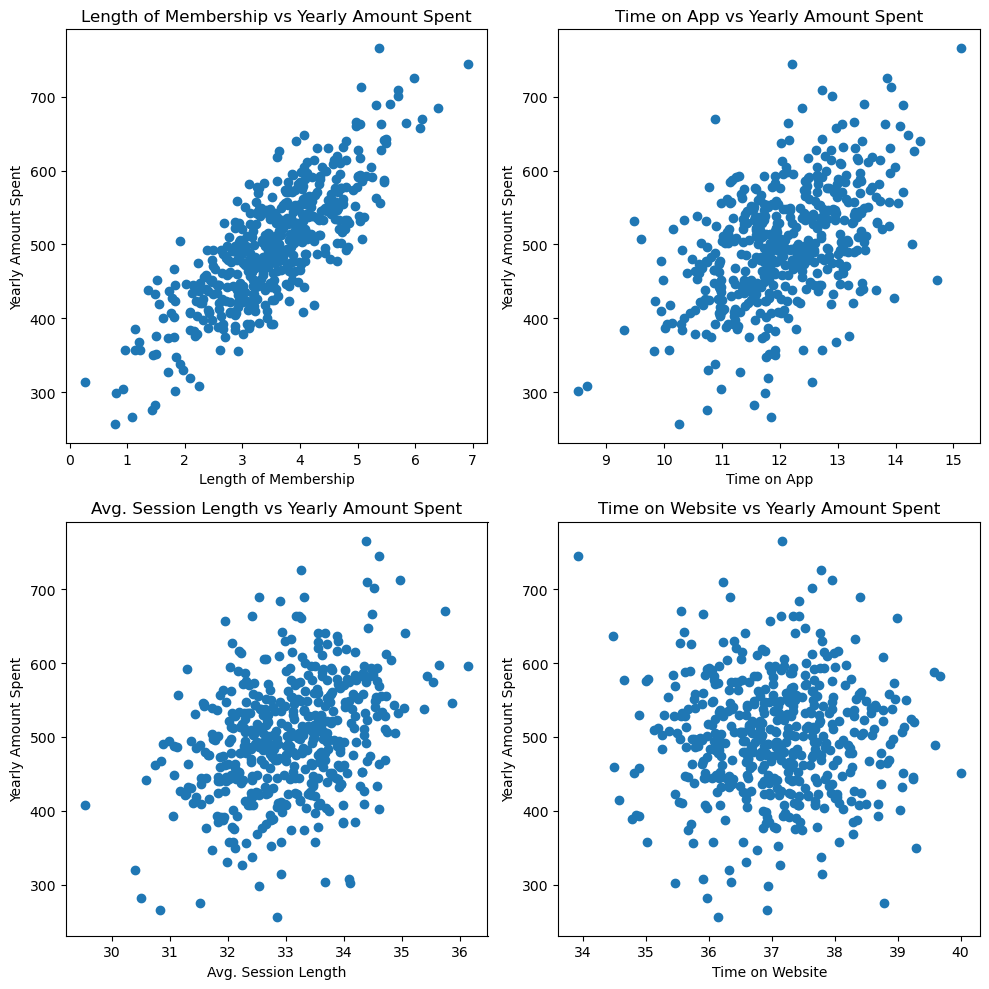

In [9]:
x_vars = ['Length of Membership', 'Time on App', 'Avg. Session Length', 'Time on Website']
y_var = 'Yearly Amount Spent'

plt.figure(figsize=(10,10))

for i, x in enumerate(x_vars, 1):
    plt.subplot(2, 2, i)
    plt.scatter(df2[x], df2[y_var])
    plt.xlabel(x)
    plt.ylabel(y_var)
    plt.title(f'{x} vs {y_var}')

plt.tight_layout()
plt.show()


### Now We can confirm that Length of Membership column has the strongest linear relationship
so we will apply simple linear regression on it

In [33]:
X = df2[['Length of Membership']]
y = df2[['Yearly Amount Spent']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state= 42)
X_test

,Length of Membership
361,3.434560
73,3.851579
374,4.238296
155,2.941411
104,3.428860
...,...
347,5.137817
86,2.669942
75,3.120569
438,3.535088


In [11]:
slr = LinearRegression()
slr.fit(X_train, y_train)

LinearRegression()

In [12]:
print("Intercept:", slr.intercept_)
print("Coefficient:", slr.coef_[0])

Intercept: [271.3521128]
Coefficient: [64.64010065]


In [13]:
y_predict = slr.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(f"MSE : {mean_squared_error(y_predict, y_test)}")
print(f"AME : {mean_absolute_error(y_predict, y_test)}")
print(f"R2 : {r2_score(y_predict, y_test)}")

MSE : 2162.1116327764244
AME : 37.83623390033242
R2 : 0.30376787830897656


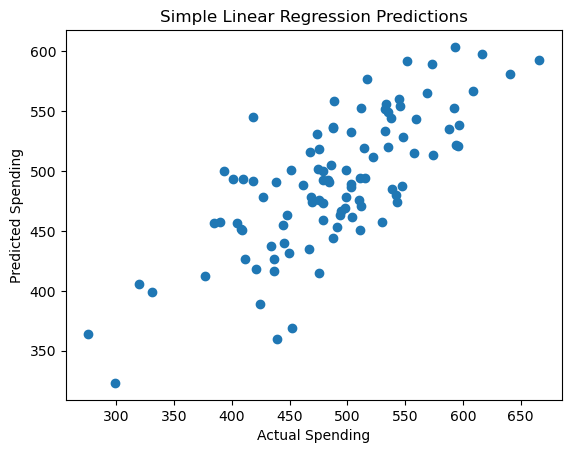

In [15]:
plt.scatter(y_test, y_predict)
plt.xlabel("Actual Spending")
plt.ylabel("Predicted Spending")
plt.title("Simple Linear Regression Predictions")
plt.show()

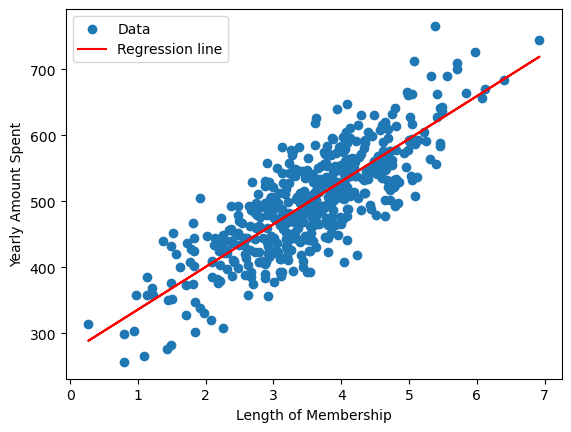

In [16]:
plt.scatter(X,y, label= "Data")
plt.plot(X, slr.coef_[0]*X+slr.intercept_, '-r', label = "Regression line")
plt.xlabel("Length of Membership")
plt.ylabel("Yearly Amount Spent")
plt.legend()
plt.show()

## Multible Linear Regression

In [17]:
df2

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438
496,34.702529,11.695736,37.190268,3.576526,529.049004
497,32.646777,11.499409,38.332576,4.958264,551.620145
498,33.322501,12.391423,36.840086,2.336485,456.469510


In [18]:
X = df2.drop("Yearly Amount Spent", axis = 1)
y = df2["Yearly Amount Spent"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test

,Length of Membership
361,3.434560
73,3.851579
374,4.238296
155,2.941411
104,3.428860
...,...
347,5.137817
86,2.669942
75,3.120569
438,3.535088


In [20]:
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)

In [21]:
print(f"Linear Model Coefficients : {lm.coef_}")
print(f"Linear Model Interceptor : {lm.intercept_}")

Linear Model Coefficients : [25.5962591  38.78534598  0.31038593 61.89682859]
Linear Model Interceptor : -1044.2574146365578


In [22]:
print(f"MSE : {mean_squared_error(y_pred, y_test)}")
print(f"MAE : {mean_absolute_error(y_pred, y_test)}")
print(f"R2 : {r2_score(y_pred, y_test)}")

MSE : 109.86374118394063
MAE : 8.558441885315263
R2 : 0.9782625350414403


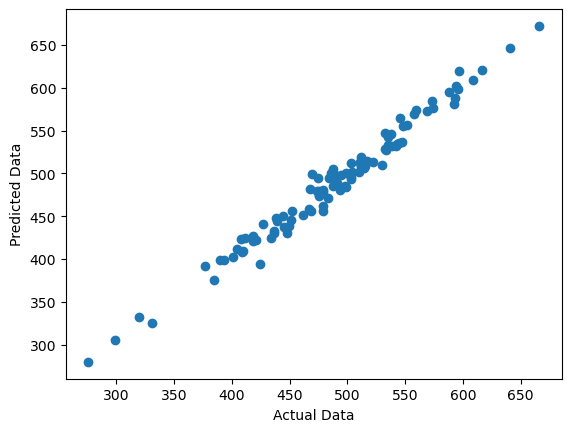

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Data")
plt.ylabel("Predicted Data")
plt.show()

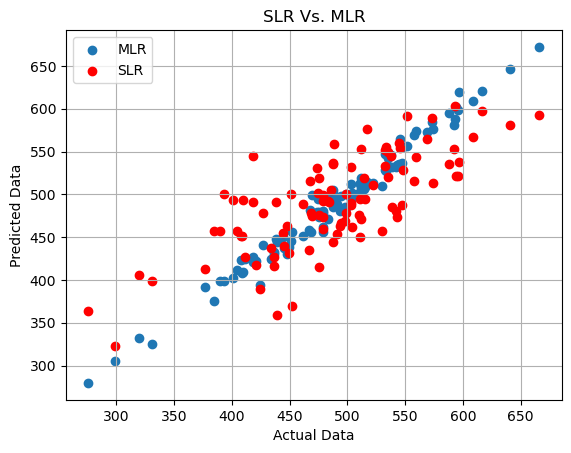

In [24]:
plt.scatter(y_test, y_pred, label = "MLR")
plt.scatter(y_test, y_predict, color = "red", label = "SLR")
plt.xlabel("Actual Data")
plt.ylabel("Predicted Data")
plt.title('SLR Vs. MLR')
plt.legend()
plt.grid(True)
plt.show()

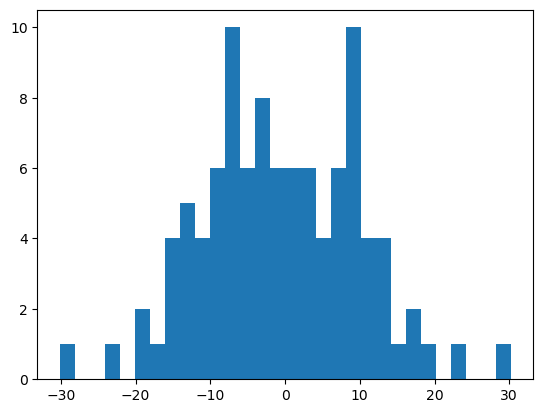

In [25]:
residuals = y_test - y_pred
plt.hist(residuals, bins=30)
plt.show()

### Apply Preprocessing before going with the model

In [26]:
df

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [27]:
X = df.iloc[:, [3,4,5,6]].to_numpy()
y = df.iloc[:, [7]].to_numpy()


In [28]:
# Import the preprocessing module from scikit-learn
from sklearn import preprocessing

# Create a StandardScaler object
# StandardScaler standardizes features by removing the mean and scaling to unit variance
std_scaler = preprocessing.StandardScaler()

# Fit the scaler to the data X and then transform it
# This produces standardized data: each feature will have mean = 0 and standard deviation = 1
X_std = std_scaler.fit_transform(X)


In [29]:
pd.DataFrame(X_std).describe().round(2)

,0,1,2,3
count,500.00,500.00,500.00,500.00
mean,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-3.55,-3.57,-3.12,-3.27
25%,-0.72,-0.67,-0.70,-0.60
50%,0.03,-0.07,0.01,0.00
75%,0.66,0.71,0.65,0.59
max,3.11,3.10,2.92,3.40


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)



Coefficients:  [[25.38048395 38.52241606  0.31332774 61.79022522]]
Intercept:  [499.45371056]


In [31]:
y_pred = regressor.predict(X_test)

In [32]:
print(f"MSE : {mean_squared_error(y_pred, y_test)}")
print(f"MAE : {mean_absolute_error(y_pred, y_test)}")
print(f"R2 : {r2_score(y_pred, y_test)}")

MSE : 109.86374118394018
MAE : 8.558441885315244
R2 : 0.9782625350414405
